# FULL CODE 31_05_more data_dataset

# Load CSV ALL

In [ ]:
import pandas as pd

# Caminho local para o ficheiro CSV
file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\database\d5_pivot_2018_2024.csv"

# Carregar o CSV
d5_filtered = pd.read_csv(file_path)

# Verificar as primeiras linhas
print(f"Ficheiro carregado com {d5_filtered.shape[0]} linhas e {d5_filtered.shape[1]} colunas.")
d5_filtered.head()


Ficheiro carregado com 6959672 linhas e 3 colunas.


,case_id,data_atributo,timestamp
0,b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908c...,DATA_ENVIO_CARTA_SENSIBIL,2019-08-05
1,09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759...,DATA_ENVIO_CARTA_SENSIBIL,2022-08-31
2,0a05a6e971554339e7901ea0e51ffab127ead72a95045a...,DATA_ENVIO_CARTA_SENSIBIL,2022-08-31
3,0a05a6e971554339e7901ea0e51ffab127ead72a95045a...,DATA_ENVIO_CARTA_SENSIBIL,2019-01-09
4,0a05a6e971554339e7901ea0e51ffab127ead72a95045a...,DATA_ENVIO_CARTA_SENSIBIL,2020-12-23


## SAVE FILE

In [ ]:
import pandas as pd

# Filter dates for timestamp column and save the new filtered DataFrame
# Define the date range for filtering
date_start = pd.to_datetime("2018-03-01")
date_end = pd.to_datetime("2025-06-30")

# Ensure that the timestamp column is properly formatted as datetime
d5_long['timestamp'] = pd.to_datetime(d5_long['timestamp'], errors='coerce', dayfirst=True)

# Filter the DataFrame based on the date range
d5_filtered = d5_long[(d5_long['timestamp'] >= date_start) & (d5_long['timestamp'] <= date_end)]

# Define the path to save the new filtered DataFrame
output_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\d5_pivot_2018_2024.csv"

# Save the filtered DataFrame to the specified location
d5_filtered.to_csv(output_file_path, index=False)

# Print confirmation message
print(f"Filtered data saved successfully to: {output_file_path}")

Filtered data saved successfully to: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\database\d5_pivot_2018_2024.csv


In [5]:
print("Summary of timestamp:")
print(d5_filtered['timestamp'].describe())

Summary of timestamp:
count                          6959672
mean     2022-05-20 22:11:35.871416064
min                2018-04-06 00:00:00
25%                2021-01-27 00:00:00
50%                2022-06-02 00:00:00
75%                2023-12-05 00:00:00
max                2025-05-07 00:00:00
Name: timestamp, dtype: object


## Load FILE

In [110]:
import pandas as pd

# Define o caminho para o ficheiro
file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\database\d5_pivot_2018_2024.csv"

# Carrega o ficheiro para um DataFrame
d5_filtered = pd.read_csv(file_path, parse_dates=['timestamp'])

# Mostra as primeiras linhas do DataFrame
print(d5_filtered.head())


                                             case_id  \
0  b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908c...   
1  09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759...   
2  0a05a6e971554339e7901ea0e51ffab127ead72a95045a...   
3  0a05a6e971554339e7901ea0e51ffab127ead72a95045a...   
4  0a05a6e971554339e7901ea0e51ffab127ead72a95045a...   

               data_atributo  timestamp  
0  DATA_ENVIO_CARTA_SENSIBIL 2019-08-05  
1  DATA_ENVIO_CARTA_SENSIBIL 2022-08-31  
2  DATA_ENVIO_CARTA_SENSIBIL 2022-08-31  
3  DATA_ENVIO_CARTA_SENSIBIL 2019-01-09  
4  DATA_ENVIO_CARTA_SENSIBIL 2020-12-23  


### Rename Activities

In [6]:
# Rename columns to comply with event log structure
d5_filtered.rename(columns={
    "data_atributo": "activity_id"
}, inplace=True)


# Rename activity_id values to ensure consistency
d5_filtered['activity_id'] = d5_filtered['activity_id'].replace({
    "DATA_ENVIO_CARTA_SENSIBIL": "Invitation_mail",
    "DATA_ENVIO_CARTA_COM_KIT": "FIT_mail",
    "DATA_RECECAO_CENTRO_SAUDE": "FIT_return",
    "DATA_EXECUCAO_CONSULTAS_MF": "PCC_observation",
    "DATA_EXECUCAO": "Colonoscopy_center",
    "DATA_RESULTADO": "Lab_result",
    "DATA_RECECAO_LABORATORIO": "Lab_return",
    "DATA_REJEICAO_CENTRO_SAUDE": "PCC_FIT_rejection",
    "DATA_REQUISICAO_CONSULTAS_MF": "PCC_fwd",
    "DATA_REJEICAO_LABORATORIO": "lab_FIT_rejection",
    "DATA_EXCLUSAO": "FIT_excluded",
    "DATA_CANCELAMENTO": "PCC_case_exclusion",
    "DATA_REJEICAO_CS_REP": "PCC_FIT_rejection"
})

# Define the path to save the new filtered DataFrame
output_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\database\d5_prelogfile.csv"

# Save the filtered DataFrame to the specified location
d5_filtered.to_csv(output_file_path, index=False)

# Print confirmation message
print(f"Filtered data with renamed activity names saved successfully to: {output_file_path}")

# List of column names to check for unique values
columns_to_check = [  "activity_id"] #"Gender", "FIT_result", "Colonoscopy_request", "PostColonoscopy_referral",

# Loop through each column and print unique values
for column_name in columns_to_check:
    unique_values = d5_filtered[column_name].unique()
    print(f"Unique values in {column_name}:\n{unique_values}\n")

Filtered data with renamed activity names saved successfully to: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\database\d5_prelogfile.csv
Unique values in activity_id:
['Invitation_mail' 'FIT_mail' 'PCC_FIT_rejection' 'FIT_return'
 'lab_FIT_rejection' 'Lab_return' 'Lab_result' 'PCC_fwd' 'PCC_observation'
 'Colonoscopy_center']



In [8]:
from datetime import datetime

# Definir as datas
date_invitation = datetime.strptime("24.04.2024", "%d.%m.%Y").date()
date_fitmail = datetime.strptime("29.05.2024", "%d.%m.%Y").date()

# Garantir que o timestamp está em datetime
d5_filtered["timestamp"] = pd.to_datetime(d5_filtered["timestamp"])

# 1. Invitation_mail → corresponde a Invitation_mail em 24.04.2024
invitation_matches = d5_filtered[
    (d5_filtered["activity_id"] == "Invitation_mail") &
    (d5_filtered["timestamp"].dt.date == date_invitation)
]

# 2. FIT_mail → se tiver outro nome, ajusta aqui!
fitmail_matches = d5_filtered[
    (d5_filtered["activity_id"] == "FIT_mail") &  # <-- troca por nome real do FIT
    (d5_filtered["timestamp"].dt.date == date_fitmail)
]

# 3. Ver duplicados de envio de carta no mesmo case_id + timestamp
invitation_duplicates = invitation_matches[
    invitation_matches.duplicated(subset=["case_id", "timestamp"], keep=False)
]

# Resultados
print(f"📨 Invitation_mail @ 24.04.2024: {len(invitation_matches)}")
print(f"📬 FIT_mail @ 29.05.2024: {len(fitmail_matches)}")
print(f"❗ Duplicados Invitation_mail (case_id + timestamp): {len(invitation_duplicates)}")

invitation_duplicates.head()


📨 Invitation_mail @ 24.04.2024: 30125
📬 FIT_mail @ 29.05.2024: 29472
❗ Duplicados Invitation_mail (case_id + timestamp): 0


,case_id,activity_id,timestamp


verificação absoluta se no CSV há casos com eventos + datas duplicados > zero

In [10]:
duplicated_global = d5_filtered.duplicated(subset=["case_id", "activity_id", "timestamp"], keep=False)
print(f"❗ Registos duplicados globais (case_id + activity_id + timestamp): {duplicated_global.sum()}")


❗ Registos duplicados globais (case_id + activity_id + timestamp): 0


## Transform Log for event data analysis

In [11]:
import pandas as pd
import numpy as np
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.objects.log.exporter.xes import exporter as xes_exporter

# Assuming d5_filtered is your dataset

# Step 1: Rename Columns to Meet pm4py Event Log Requirements
d5_filtered.rename(columns={
    'case_id': 'case:concept:name',     # Case identifier
    'activity_id': 'concept:name',      # Activity name
    'timestamp': 'time:timestamp'#,      # Timestamp for each activity
    #'resource_id': 'org:resource'       # Resource performing the activity
}, inplace=True)

# Step 2: Ensure 'time:timestamp' is in the Correct Datetime Format
d5_filtered['time:timestamp'] = pd.to_datetime(d5_filtered['time:timestamp'])

# Step 3: Convert the DataFrame to the Appropriate Format for pm4py
# Convert timestamp columns in the DataFrame for pm4py compatibility
d5_filtered = dataframe_utils.convert_timestamp_columns_in_df(d5_filtered)

# Step 4: Convert DataFrame to an Event Log
parameters = {
    "case_id_key": 'case:concept:name',
    "activity_key": 'concept:name',
    "timestamp_key": 'time:timestamp'#,
    #"resource_key": 'org:resource'
}

# Apply the conversion
event_log = log_converter.apply(d5_filtered, 
                                variant=log_converter.Variants.TO_EVENT_LOG, 
                                parameters=parameters)


In [12]:
print("Displaying the first 10 traces with ALL event attributes:")

for idx, trace in enumerate(event_log[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event_num, event in enumerate(trace):
        print(f"  Evento {event_num+1}:")
        for key, value in event.items():
            print(f"    {key}: {value}")


Displaying the first 10 traces with ALL event attributes:

Trace 1 (Case ID: b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908cd9208e85f0ae0e67e4):
  Evento 1:
    concept:name: Invitation_mail
    time:timestamp: 2019-08-05 00:00:00+00:00
  Evento 2:
    concept:name: FIT_mail
    time:timestamp: 2019-09-09 00:00:00+00:00
  Evento 3:
    concept:name: PCC_FIT_rejection
    time:timestamp: 2020-08-28 00:00:00+00:00

Trace 2 (Case ID: 09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759885191656885296c6c):
  Evento 1:
    concept:name: Invitation_mail
    time:timestamp: 2022-08-31 00:00:00+00:00
  Evento 2:
    concept:name: FIT_mail
    time:timestamp: 2022-10-05 00:00:00+00:00
  Evento 3:
    concept:name: PCC_FIT_rejection
    time:timestamp: 2024-02-07 00:00:00+00:00

Trace 3 (Case ID: 0a05a6e971554339e7901ea0e51ffab127ead72a95045ad1da504a155d49a342):
  Evento 1:
    concept:name: Invitation_mail
    time:timestamp: 2022-08-31 00:00:00+00:00
  Evento 2:
    concept:name: Invitation_mail
    

In [13]:
# Step 1: View the first 10 traces of the event log
print("Displaying the first 10 traces in the event log:")
for idx, trace in enumerate(event_log[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event in trace:
        print(f"  Activity: {event['concept:name']}, Timestamp: {event['time:timestamp']}") #, Resource: {event.get('org:resource', 'N/A')}


Displaying the first 10 traces in the event log:

Trace 1 (Case ID: b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908cd9208e85f0ae0e67e4):
  Activity: Invitation_mail, Timestamp: 2019-08-05 00:00:00+00:00
  Activity: FIT_mail, Timestamp: 2019-09-09 00:00:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2020-08-28 00:00:00+00:00

Trace 2 (Case ID: 09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759885191656885296c6c):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:00:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:00:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2024-02-07 00:00:00+00:00

Trace 3 (Case ID: 0a05a6e971554339e7901ea0e51ffab127ead72a95045ad1da504a155d49a342):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:00:00+00:00
  Activity: Invitation_mail, Timestamp: 2019-01-09 00:00:00+00:00
  Activity: Invitation_mail, Timestamp: 2020-12-23 00:00:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:00:00+00:00
  Activity: FIT_mail, Timestamp: 2019-02-13 00:00:

## SAVE CSV and XES MASTER FILE

#### CSV

In [17]:


import pandas as pd

# Step 5: Manually Convert the Event Log to a DataFrame
log_data = []

for trace in event_log:
    case_id = trace.attributes['concept:name']
    for event in trace:
        log_data.append({
            'case_id': case_id,
            'activity': event['concept:name'],
            'timestamp': event['time:timestamp']
        })

# Convert the collected data into a DataFrame
event_log_df = pd.DataFrame(log_data)

# Step 6: Save the DataFrame as CSV to the specified path
filename_csv = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_ALL.csv"
event_log_df.to_csv(filename_csv, index=False)

print(f"✅ Event log saved at:\n{filename_csv}")


✅ Event log saved at:
C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_ALL.csv


#### IMport CSV

In [18]:
import pandas as pd

csv_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_ALL.csv"

df = pd.read_csv(csv_path)

print("Colunas do ficheiro:", df.columns.tolist())
print(df.head())


Colunas do ficheiro: ['case_id', 'activity', 'timestamp']
                                             case_id           activity  \
0  b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908c...    Invitation_mail   
1  b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908c...           FIT_mail   
2  b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908c...  PCC_FIT_rejection   
3  09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759...    Invitation_mail   
4  09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759...           FIT_mail   

                   timestamp  
0  2019-08-05 00:00:00+00:00  
1  2019-09-09 00:00:00+00:00  
2  2020-08-28 00:00:00+00:00  
3  2022-08-31 00:00:00+00:00  
4  2022-10-05 00:00:00+00:00  


In [19]:
import os
print("Ficheiro gravado em:", os.path.abspath(filename_csv))


Ficheiro gravado em: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_ALL.csv


#### XES save

In [20]:
import os
from pm4py.objects.log.exporter.xes import exporter as xes_exporter

# Define the output path (same folder you mentioned)
output_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025"

# Use the same base filename logic
base_filename = "event_log_ALL"

# Construct full path for XES file
filename_xes = f"{base_filename}.xes"
xes_path = os.path.join(output_file_path, filename_xes)

# Save the event_log object directly to XES
xes_exporter.apply(event_log, xes_path)

print(f"Event log saved in XES format as '{xes_path}'")


c:\Users\hugof\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
exporting log, completed traces :: 100%|██████████| 1183369/1183369 [01:18<00:00, 15028.80it/s]

Event log saved in XES format as 'C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_ALL.xes'


In [21]:
# Estatísticas do event_log carregado (do tipo EventLog do pm4py)
total_cases = len(event_log)
total_events = sum(len(trace) for trace in event_log)
average_events = total_events / total_cases if total_cases > 0 else 0

print("📊 Resumo do Event Log")
print(f"📦 Total de casos (traces): {total_cases}")
print(f"🔢 Total de eventos: {total_events}")
print(f"➗ Média de eventos por caso: {average_events:.2f}")


📊 Resumo do Event Log
📦 Total de casos (traces): 1183369
🔢 Total de eventos: 6959672
➗ Média de eventos por caso: 5.88


In [23]:
from datetime import datetime, time
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from pm4py.objects.log.obj import EventLog, Trace

# 1. Criar novo EventLog com timestamps normalizados
standardized_log = EventLog()

for trace in event_log:
    new_events = []
    for event in trace:
        original_date = event["time:timestamp"].date()
        new_event = {key: value for key, value in event.items()}
        new_event["time:timestamp"] = datetime.combine(original_date, time(0, 1))  # 00:01:00 fixo
        new_events.append(new_event)

    new_trace = Trace(new_events, attributes=dict(trace.attributes))
    standardized_log.append(new_trace)

# 2. Guardar o novo XES
output_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_FIXED.xes"
xes_exporter.apply(standardized_log, output_path)

print(f"✅ XES exportado com timestamps normalizados para 00:01:00:\n{output_path}")


exporting log, completed traces :: 100%|██████████| 1183369/1183369 [01:17<00:00, 15203.44it/s]

✅ XES exportado com timestamps normalizados para 00:01:00:
C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_FIXED.xes


In [25]:
# Estatísticas do standardized_log carregado
total_cases = len(standardized_log)
total_events = sum(len(trace) for trace in standardized_log)
average_events = total_events / total_cases if total_cases > 0 else 0

print("📊 Resumo do Event Log (standardized)")
print(f"📦 Total de casos (traces): {total_cases}")
print(f"🔢 Total de eventos: {total_events}")
print(f"➗ Média de eventos por caso: {average_events:.2f}")


📊 Resumo do Event Log (standardized)
📦 Total de casos (traces): 1183369
🔢 Total de eventos: 6959672
➗ Média de eventos por caso: 5.88


In [61]:
# Ver os primeiros 5 casos (traces)
for i, trace in enumerate(standardized_log[:5]):
    case_id = trace.attributes.get("concept:name", f"Trace {i}")
    print(f"\n🧾 Trace {i+1} — Case ID: {case_id} — {len(trace)} eventos")
    for event in trace:
        print(f"  {event['time:timestamp']} — {event['concept:name']}")



🧾 Trace 1 — Case ID: b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908cd9208e85f0ae0e67e4 — 3 eventos
  2019-08-05 00:01:00 — Invitation_mail
  2019-09-09 00:01:00 — FIT_mail
  2020-08-28 00:01:00 — PCC_FIT_rejection

🧾 Trace 2 — Case ID: 09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759885191656885296c6c — 3 eventos
  2022-08-31 00:01:00 — Invitation_mail
  2022-10-05 00:01:00 — FIT_mail
  2024-02-07 00:01:00 — PCC_FIT_rejection

🧾 Trace 3 — Case ID: 0a05a6e971554339e7901ea0e51ffab127ead72a95045ad1da504a155d49a342 — 9 eventos
  2022-08-31 00:01:00 — Invitation_mail
  2019-01-09 00:01:00 — Invitation_mail
  2020-12-23 00:01:00 — Invitation_mail
  2022-10-05 00:01:00 — FIT_mail
  2019-02-13 00:01:00 — FIT_mail
  2021-01-27 00:01:00 — FIT_mail
  2024-02-07 00:01:00 — PCC_FIT_rejection
  2020-08-27 00:01:00 — PCC_FIT_rejection
  2022-02-08 00:01:00 — PCC_FIT_rejection

🧾 Trace 4 — Case ID: c3d6d5c4a21e4fd3e3112258ec3f29d1a5deb594e4de24016e63635db23c2920 — 3 eventos
  2019-08-05 00:01:00 — Invit

In [30]:
from datetime import datetime, time
from pm4py.objects.log.obj import EventLog, Trace
from pm4py.objects.log.exporter.xes import exporter as xes_exporter

# Novo log limpo e normalizado
cleaned_standardized_log = EventLog()

for trace in event_log:
    new_events = []
    previous_event = None

    for event in trace:
        # Normalizar timestamp para 00:01:00
        original_date = event["time:timestamp"].date()
        fixed_timestamp = datetime.combine(original_date, time(0, 1)).replace(tzinfo=None)

        # Copiar evento
        new_event = {key: value for key, value in event.items()}
        new_event["time:timestamp"] = fixed_timestamp

        # Verifica duplicados consecutivos
        if previous_event is None or not (
            new_event["concept:name"] == previous_event["concept:name"] and
            new_event["time:timestamp"] == previous_event["time:timestamp"]
        ):
            new_events.append(new_event)
            previous_event = new_event

    # Construir nova trace com atributos
    new_trace = Trace(new_events, attributes=dict(trace.attributes))
    cleaned_standardized_log.append(new_trace)

# Exportar
output_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_CLEAN_FIXED_0001.xes"
xes_exporter.apply(cleaned_standardized_log, output_path)

print("✅ Ficheiro XES exportado com timestamps normalizados e sem duplicados consecutivos:")
print(output_path)


exporting log, completed traces :: 100%|██████████| 1183369/1183369 [01:26<00:00, 13729.87it/s]

✅ Ficheiro XES exportado com timestamps normalizados e sem duplicados consecutivos:
C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_CLEAN_FIXED_0001.xes


In [6]:
import pandas as pd

# Your target case ID
target_case_id = "b9dcdbf978f46ef2bc029aff9889094710eb85603cf7253166ba1641062ff047"

# Find and extract the trace
for trace in event_log:
    if trace.attributes.get("concept:name") == target_case_id:
        events_data = [
            {
                "activity": event["concept:name"],
                "timestamp": event["time:timestamp"],
                **{k: v for k, v in event.items() if k not in ["concept:name", "time:timestamp"]}
            }
            for event in trace
        ]
        trace_df = pd.DataFrame(events_data)
        break
else:
    trace_df = pd.DataFrame()  # If not found

# Just show the DataFrame!
trace_df  # In Jupyter this will display nicely



NameError: name 'event_log' is not defined

# START HERE_LOAD DATASET

## Load XES FILE_FULL

In [1]:
from pm4py.objects.log.importer.xes import importer as xes_importer

# Caminho completo para o ficheiro XES
xes_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_CLEAN_FIXED_0001.xes"

# Carregar o log de eventos XES
try:
    event_log_xes = xes_importer.apply(xes_file_path)
    print("Loaded XES event log successfully.")

    # Exibir as primeiras 10 traces (linhas) do log para inspeção
    for i, trace in enumerate(event_log_xes[:10]):
        print(f"Trace {i + 1}:")
        for event in trace:
            print(event)
        print("-" * 40)
except Exception as e:
    print(f"An error occurred while loading the XES file: {e}")

c:\Users\hugof\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 1183369/1183369 [01:46<00:00, 11092.86it/s]

Loaded XES event log successfully.
Trace 1:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2019, 8, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2019, 9, 9, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2020, 8, 28, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 2:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2022, 10, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2024, 2, 7, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 3:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name'

In [2]:
# Step 1: View the first 10 traces of the event log
print("Displaying the first 10 traces in the event log:")
for idx, trace in enumerate(event_log_xes[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event in trace:
        print(f"  Activity: {event['concept:name']}, Timestamp: {event['time:timestamp']}") #, Resource: {event.get('org:resource', 'N/A')}

Displaying the first 10 traces in the event log:

Trace 1 (Case ID: b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908cd9208e85f0ae0e67e4):
  Activity: Invitation_mail, Timestamp: 2019-08-05 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2019-09-09 00:01:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2020-08-28 00:01:00+00:00

Trace 2 (Case ID: 09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759885191656885296c6c):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:01:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2024-02-07 00:01:00+00:00

Trace 3 (Case ID: 0a05a6e971554339e7901ea0e51ffab127ead72a95045ad1da504a155d49a342):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:01:00+00:00
  Activity: Invitation_mail, Timestamp: 2019-01-09 00:01:00+00:00
  Activity: Invitation_mail, Timestamp: 2020-12-23 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2019-02-13 00:01:

# POST 2024 test dataset

In [5]:
from pm4py.algo.filtering.log.timestamp.timestamp_filter import filter_traces_contained
from datetime import datetime, timezone

# Lower time limit (Keep only cases from 2024 onwards)
date_threshold = datetime(2024, 1, 1, tzinfo=timezone.utc)

# Upper limit to avoid issues with None timestamps
date_upper_limit = datetime.max  # Avoids `None` issues

# Apply initial filtering: Keep traces where at least one event happens in 2024+
filtered_log = filter_traces_contained(
    log= event_log_xes,
    dt1=date_threshold,
    dt2=date_upper_limit,  # Explicit upper limit
    parameters={"timestamp_key": "time:timestamp"}
)

# ✅ Now apply additional filtering: Keep only traces where the first event is "Invitation_mail"
filtered_invitation_log = []
for trace in filtered_log:
    if trace and trace[0]["concept:name"] == "Invitation_mail":
        filtered_invitation_log.append(trace)

# Step 1: View the first 10 traces of the event log
print("Displaying the first 10 traces in the event log:")
for idx, trace in enumerate(filtered_invitation_log[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event in trace:
        print(f"  Activity: {event['concept:name']}, Timestamp: {event['time:timestamp']}") #, Resource: {event.get('org:resource', 'N/A')}


Displaying the first 10 traces in the event log:

Trace 1 (Case ID: 8145dd6697511042fd75b97795fc829f777c6cdd8a5b53014539e057215dc04c):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 2 (Case ID: d093dde57bc81bb95c69b0f28d2eae3aca3033b946c43e5f35b0492dffd47eff):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 3 (Case ID: ac614202c511140c8c1154c913d257ba66cb23bb5414c3f5422fea772641b3a0):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 4 (Case ID: 6d01c1f58af4beb5221cfec29c1e39b9d78d3efc2e076fbb3ebb34d42475985f):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 5 (Case ID: 7bb1e90a20a44ab43d22400a1aba7b3647590f0e80159d353dfe619443be2eb9):
  Activity: Invitatio

### Check dates

In [7]:
import pandas as pd

# ✅ Summary of timestamps for only 'Invitation_mail' activities from 1/6/2023 onwards
timestamps_invitation = []
for trace in filtered_invitation_log:
    for event in trace:
        if event["concept:name"] == "Invitation_mail" and event["time:timestamp"] >= date_threshold:
            timestamps_invitation.append(event["time:timestamp"])

timestamps_invitation_df = pd.DataFrame(timestamps_invitation, columns=["timestamp"])
timestamps_invitation_df["timestamp"] = pd.to_datetime(timestamps_invitation_df["timestamp"])
print("Timestamp Summary for 'Invitation_mail':")
print(timestamps_invitation_df.describe())

Timestamp Summary for 'Invitation_mail':
                                 timestamp
count                               140870
mean   2024-08-15 15:04:37.885994752+00:00
min              2024-01-15 00:01:00+00:00
25%              2024-04-16 00:01:00+00:00
50%              2024-08-13 00:01:00+00:00
75%              2024-12-23 00:01:00+00:00
max              2025-05-07 00:01:00+00:00


### check activities freq ___ ALL

In [8]:
# Get all 'Invitation_mail' timestamps from your event log
timestamps = []
for trace in event_log_xes:
    for event in trace:
        if event["concept:name"] == "Invitation_mail":
            timestamps.append(event["time:timestamp"])


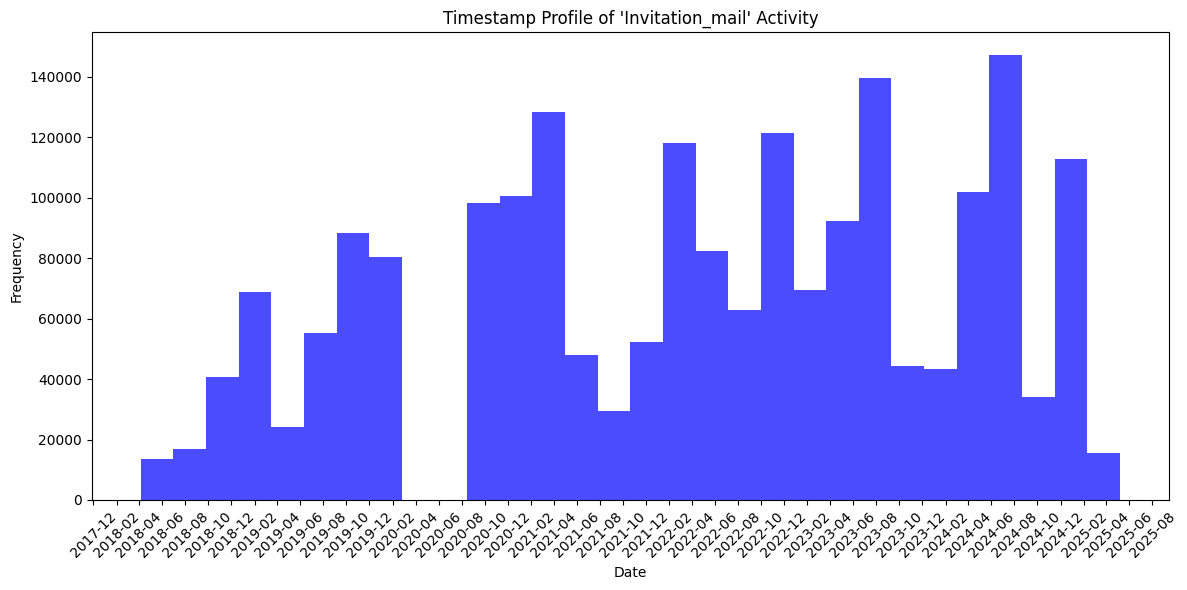

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.hist(timestamps, bins=30, color='blue', alpha=0.7)
plt.title("Timestamp Profile of 'Invitation_mail' Activity")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### check activites freq_ post 2024

In [10]:
# Get all 'Invitation_mail' timestamps from your event log
timestamps = []
for trace in filtered_invitation_log:
    for event in trace:
        if event["concept:name"] == "Invitation_mail":
            timestamps.append(event["time:timestamp"])

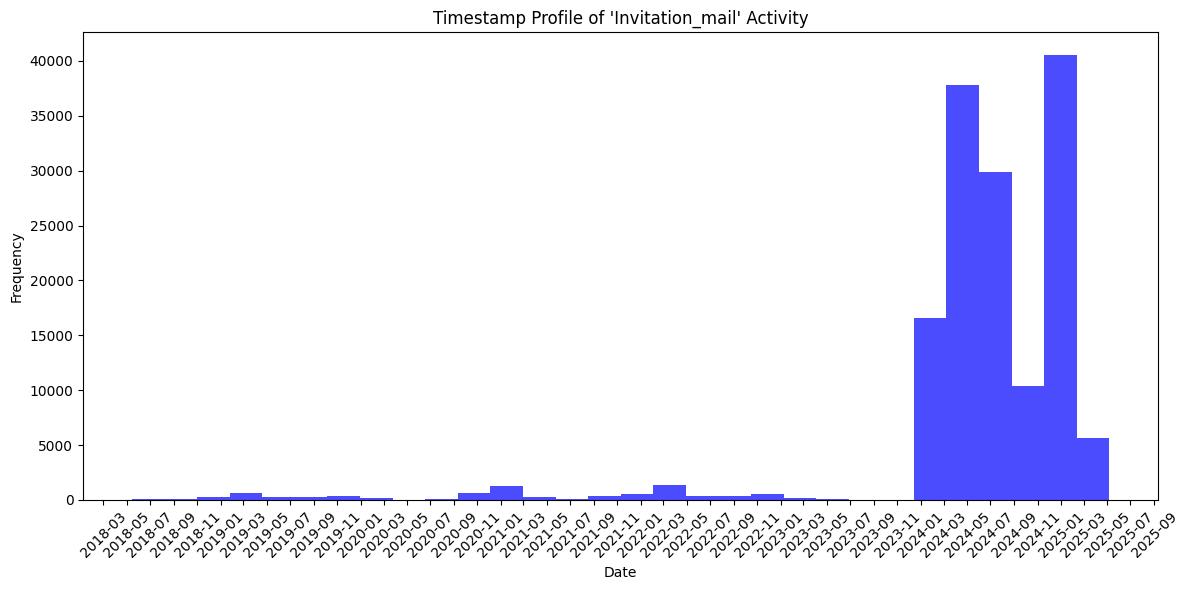

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.hist(timestamps, bins=30, color='blue', alpha=0.7)
plt.title("Timestamp Profile of 'Invitation_mail' Activity")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Discover Process

In [12]:
unique_activities = set()

for trace in filtered_invitation_log:
    for event in trace:
        activity_name = event["concept:name"]
        unique_activities.add(activity_name)

print("Unique activities in the filtered log:")
for activity in unique_activities:
    print(activity)

Unique activities in the filtered log:
FIT_mail
Lab_result
PCC_observation
Colonoscopy_center
lab_FIT_rejection
Lab_return
PCC_fwd
Invitation_mail
FIT_return
PCC_FIT_rejection


#### discover with heuristics

In [13]:
import pandas as pd

# Your target case ID
target_case_id = "b9dcdbf978f46ef2bc029aff9889094710eb85603cf7253166ba1641062ff047"

# Find and extract the trace
for trace in filtered_invitation_log:
    if trace.attributes.get("concept:name") == target_case_id:
        events_data = [
            {
                "activity": event["concept:name"],
                "timestamp": event["time:timestamp"],
                **{k: v for k, v in event.items() if k not in ["concept:name", "time:timestamp"]}
            }
            for event in trace
        ]
        trace_df = pd.DataFrame(events_data)
        break
else:
    trace_df = pd.DataFrame()  # If not found

# Just show the DataFrame!
trace_df  # In Jupyter this will display nicely

,activity,timestamp
0,Invitation_mail,2024-04-24 00:01:00+00:00
1,Invitation_mail,2021-03-19 00:01:00+00:00
2,FIT_mail,2024-05-29 00:01:00+00:00
3,FIT_mail,2021-04-23 00:01:00+00:00
4,FIT_return,2021-10-20 00:01:00+00:00
5,Lab_return,2021-10-29 00:01:00+00:00
6,Lab_result,2021-10-29 00:01:00+00:00


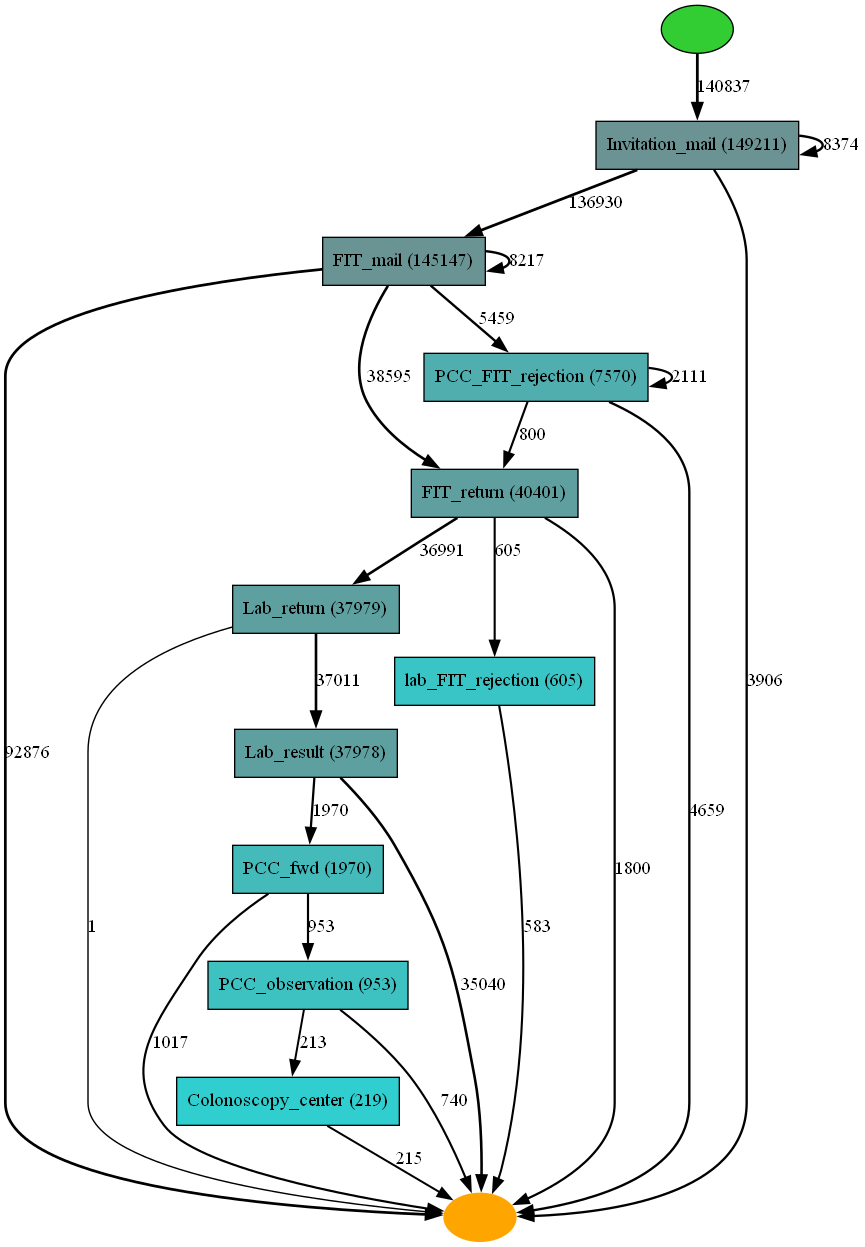

In [14]:
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer

# Filtrar traços que começam com a atividade "Invitation_mail" após 01/01/2024
filtered_traces = []
for trace in filtered_invitation_log:
    if trace[0]["concept:name"] == "Invitation_mail":
        filtered_traces.append(trace)

# Criar um log filtrado para traços válidos
from pm4py.objects.log.obj import EventLog
filtered_start_log = EventLog(filtered_traces)

# Descobrir o processo com Heuristics Miner
heu_net = heuristics_miner.apply_heu(filtered_start_log)

# Visualizar o grafo de fluxo direto
gviz = hn_visualizer.apply(heu_net)
hn_visualizer.view(gviz)


### SAVING FILE post 2024

In [15]:
from pm4py.algo.filtering.log.timestamp.timestamp_filter import filter_traces_contained
from pm4py.objects.log.obj import EventLog, Trace, Event
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from datetime import datetime
import pandas as pd

# ✅ Convert filtered log to EventLog format for proper XES export
event_log = EventLog()
for trace in filtered_invitation_log:
    new_trace = Trace()
    for event in trace:
        new_event = Event(event)
        new_trace.append(new_event)
    event_log.append(new_trace)

# ✅ Save dataset in the specified folder
output_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\post_2024_train_data_ALL.xes"
xes_exporter.apply(event_log, output_path)
print(f"Filtered log saved at: {output_path}")


exporting log, completed traces :: 100%|██████████| 140837/140837 [00:04<00:00, 34235.92it/s]

Filtered log saved at: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\post_2024_train_data_ALL.xes


In [30]:
from pm4py.algo.filtering.log.timestamp.timestamp_filter import filter_traces_contained
from pm4py.objects.log.obj import EventLog, Trace, Event
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from datetime import datetime
import pandas as pd

event_log = EventLog()
for trace in filtered_invitation_log:
    new_trace = Trace()
    # Get case ID from original trace attributes, or fallback to an index if missing
    case_id = trace.attributes.get('concept:name', f'Trace_{len(event_log) + 1}')
    new_trace.attributes["concept:name"] = case_id  # <-- This line is CRUCIAL!
    for event in trace:
        new_event = Event(event)
        new_trace.append(new_event)
    event_log.append(new_trace)

output_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\post_2024_train_data_ALL.xes"
xes_exporter.apply(event_log, output_path)
print(f"Filtered log saved at: {output_path}")


exporting log, completed traces :: 100%|██████████| 140837/140837 [00:05<00:00, 27885.81it/s]

Filtered log saved at: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\post_2024_train_data_ALL.xes


# PRE 2024 dataset

In [16]:
from pm4py.objects.log.importer.xes import importer as xes_importer ### LOAD xes_ALL

# Caminho completo para o ficheiro XES
xes_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\event_log_CLEAN_FIXED_0001.xes"

# Carregar o log de eventos XES
try:
    event_log_xes = xes_importer.apply(xes_file_path)
    print("Loaded XES event log successfully.")

    # Exibir as primeiras 10 traces (linhas) do log para inspeção
    for i, trace in enumerate(event_log_xes[:10]):
        print(f"Trace {i + 1}:")
        for event in trace:
            print(event)
        print("-" * 40)
except Exception as e:
    print(f"An error occurred while loading the XES file: {e}")

parsing log, completed traces :: 100%|██████████| 1183369/1183369 [01:53<00:00, 10435.16it/s]


Loaded XES event log successfully.
Trace 1:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2019, 8, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2019, 9, 9, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2020, 8, 28, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 2:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2022, 10, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2024, 2, 7, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 3:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name'

In [19]:
# Step 1: View the first 10 traces of the event log
print("Displaying the first 10 traces in the event log:")
for idx, trace in enumerate(event_log_xes[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event in trace:
        print(f"  Activity: {event['concept:name']}, Timestamp: {event['time:timestamp']}") #, Resource: {event.get('org:resource', 'N/A')}

Displaying the first 10 traces in the event log:

Trace 1 (Case ID: b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908cd9208e85f0ae0e67e4):
  Activity: Invitation_mail, Timestamp: 2019-08-05 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2019-09-09 00:01:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2020-08-28 00:01:00+00:00

Trace 2 (Case ID: 09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759885191656885296c6c):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:01:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2024-02-07 00:01:00+00:00

Trace 3 (Case ID: 0a05a6e971554339e7901ea0e51ffab127ead72a95045ad1da504a155d49a342):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:01:00+00:00
  Activity: Invitation_mail, Timestamp: 2019-01-09 00:01:00+00:00
  Activity: Invitation_mail, Timestamp: 2020-12-23 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2019-02-13 00:01:

## FILTER pre_2024 and save xes

In [17]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from pm4py.objects.log.obj import EventLog
from datetime import datetime, timezone

# Caminho de saída para o arquivo XES filtrado
output_xes_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\filtered_log_pre_2024.xes"

# Definir a data inicial para filtrar
start_date = datetime(2018, 5, 1, tzinfo=timezone.utc)
end_date = datetime(2024, 1, 1, tzinfo=timezone.utc)

# Filtrar o log por traces que começam com 'Invitation_mail' e estão dentro do intervalo de datas
filtered_traces = []
for trace in event_log_xes:  # Usando o log carregado corretamente
    if trace and trace[0]["concept:name"] == "Invitation_mail":
        event_timestamp = trace[0]["time:timestamp"]
        
        # Converter para datetime se necessário
        if isinstance(event_timestamp, str):
            event_timestamp = datetime.fromisoformat(event_timestamp)
        
        # Garantir que todos os timestamps têm timezone UTC
        if event_timestamp.tzinfo is None:
            event_timestamp = event_timestamp.replace(tzinfo=timezone.utc)
        
        # Comparar datas corretamente
        if start_date <= event_timestamp < end_date:
            filtered_traces.append(trace)

# Criar o log filtrado
filtered_pre_2024_log = EventLog(filtered_traces)

# Exportar o log filtrado como arquivo XES
xes_exporter.apply(filtered_pre_2024_log, output_xes_path)
print(f"Filtered log saved to: {output_xes_path}")


exporting log, completed traces :: 100%|██████████| 1042520/1042520 [01:18<00:00, 13357.81it/s]

Filtered log saved to: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\filtered_log_pre_2024.xes


In [23]:
# Step 1: View the first 10 traces of the event log
print("Displaying the first 10 traces in the event log:")
for idx, trace in enumerate(event_log_xes[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event in trace:
        print(f"  Activity: {event['concept:name']}, Timestamp: {event['time:timestamp']}") #, Resource: {event.get('org:resource', 'N/A')}

Displaying the first 10 traces in the event log:

Trace 1 (Case ID: b7463648ef877b1f4df238aebf2a2b66d8d0af32ca908cd9208e85f0ae0e67e4):
  Activity: Invitation_mail, Timestamp: 2019-08-05 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2019-09-09 00:01:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2020-08-28 00:01:00+00:00

Trace 2 (Case ID: 09c83dc2573d9081b02d4a995f9e2e045eb3a1a3a17759885191656885296c6c):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:01:00+00:00
  Activity: PCC_FIT_rejection, Timestamp: 2024-02-07 00:01:00+00:00

Trace 3 (Case ID: 0a05a6e971554339e7901ea0e51ffab127ead72a95045ad1da504a155d49a342):
  Activity: Invitation_mail, Timestamp: 2022-08-31 00:01:00+00:00
  Activity: Invitation_mail, Timestamp: 2019-01-09 00:01:00+00:00
  Activity: Invitation_mail, Timestamp: 2020-12-23 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2022-10-05 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2019-02-13 00:01:

# START HERE if ALL files clean and created

### LOAD POST 2024

In [31]:
from pm4py.objects.log.importer.xes import importer as xes_importer

# Caminho completo para o ficheiro XES
xes_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\post_2024_train_data_ALL.xes"

# Carregar o log de eventos XES
try:
    event_log_xes_post2024 = xes_importer.apply(xes_file_path)
    print("Loaded XES event log successfully.")

    # Exibir as primeiras 10 traces (linhas) do log para inspeção
    for i, trace in enumerate(event_log_xes[:10]):
        print(f"Trace {i + 1}:")
        for event in trace:
            print(event)
        print("-" * 40)
except Exception as e:
    print(f"An error occurred while loading the XES file: {e}")

parsing log, completed traces :: 100%|██████████| 140837/140837 [00:13<00:00, 10124.03it/s]


Loaded XES event log successfully.
Trace 1:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2019, 8, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2019, 9, 9, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2020, 8, 28, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 2:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2022, 10, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2024, 2, 7, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 3:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name'

In [33]:
# Step 1: View the first 10 traces of the event log
print("Displaying the first 10 traces in the event log:")
for idx, trace in enumerate(event_log_xes_post2024[:10]):
    print(f"\nTrace {idx + 1} (Case ID: {trace.attributes['concept:name']}):")
    for event in trace:
        print(f"  Activity: {event['concept:name']}, Timestamp: {event['time:timestamp']}") #, Resource: {event.get('org:resource', 'N/A')}


Displaying the first 10 traces in the event log:

Trace 1 (Case ID: 8145dd6697511042fd75b97795fc829f777c6cdd8a5b53014539e057215dc04c):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 2 (Case ID: d093dde57bc81bb95c69b0f28d2eae3aca3033b946c43e5f35b0492dffd47eff):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 3 (Case ID: ac614202c511140c8c1154c913d257ba66cb23bb5414c3f5422fea772641b3a0):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 4 (Case ID: 6d01c1f58af4beb5221cfec29c1e39b9d78d3efc2e076fbb3ebb34d42475985f):
  Activity: Invitation_mail, Timestamp: 2024-04-24 00:01:00+00:00
  Activity: FIT_mail, Timestamp: 2024-05-29 00:01:00+00:00

Trace 5 (Case ID: 7bb1e90a20a44ab43d22400a1aba7b3647590f0e80159d353dfe619443be2eb9):
  Activity: Invitatio

In [22]:
for idx, trace in enumerate(event_log_xes_post2024[:1]):
    print(f"Trace attributes: {trace.attributes}")
    for event in trace:
        print(f"Event keys: {list(event.keys())}")
        print(f"Event: {event}")


Trace attributes: {}
Event keys: ['concept:name', 'time:timestamp']
Event: {'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2024, 4, 24, 0, 1, tzinfo=datetime.timezone.utc)}
Event keys: ['concept:name', 'time:timestamp']
Event: {'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2024, 5, 29, 0, 1, tzinfo=datetime.timezone.utc)}


#### stats

In [34]:
import pm4py

# If not already imported:
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter

# 1. Convert the EventLog to a DataFrame
event_log_df = log_converter.apply(event_log_xes_post2024, variant=log_converter.Variants.TO_DATA_FRAME)

# 2. Clean up DataFrame column names (optional, but good practice)
event_log_df = dataframe_utils.convert_timestamp_columns_in_df(event_log_df)

# 3. View the first rows as a table
event_log_df.head()


,concept:name,time:timestamp,case:concept:name
0,Invitation_mail,2024-04-24 00:01:00+00:00,8145dd6697511042fd75b97795fc829f777c6cdd8a5b53...
1,FIT_mail,2024-05-29 00:01:00+00:00,8145dd6697511042fd75b97795fc829f777c6cdd8a5b53...
2,Invitation_mail,2024-04-24 00:01:00+00:00,d093dde57bc81bb95c69b0f28d2eae3aca3033b946c43e...
3,FIT_mail,2024-05-29 00:01:00+00:00,d093dde57bc81bb95c69b0f28d2eae3aca3033b946c43e...
4,Invitation_mail,2024-04-24 00:01:00+00:00,ac614202c511140c8c1154c913d257ba66cb23bb5414c3...


In [35]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from pm4py.objects.log.obj import EventLog
from datetime import datetime, timezone
import pandas as pd
from collections import Counter

# Gerar estatísticas descritivas básicas
total_traces = len(event_log_xes_post2024)
total_events = sum(len(trace) for trace in event_log_xes_post2024)

# Contagem de eventos por tipo
event_counts = Counter(event["concept:name"] for trace in event_log_xes_post2024 for event in trace)

# Criar DataFrame para exibir estatísticas
descriptive_stats = pd.DataFrame.from_dict(event_counts, orient='index', columns=['Frequency'])
descriptive_stats = descriptive_stats.sort_values(by='Frequency', ascending=False)

print(f"Total number of traces: {total_traces}")
print(f"Total number of events: {total_events}")
print("Event type distribution:")
print(descriptive_stats)

Total number of traces: 140837
Total number of events: 422033
Event type distribution:
                    Frequency
Invitation_mail        149211
FIT_mail               145147
FIT_return              40401
Lab_return              37979
Lab_result              37978
PCC_FIT_rejection        7570
PCC_fwd                  1970
PCC_observation           953
lab_FIT_rejection         605
Colonoscopy_center        219


#### tracing post_2024

C:\Users\hugof\AppData\Local\Temp\ipykernel_25340\2230237654.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  activity_colors = {act: plt.cm.get_cmap("tab10")(i) for i, act in enumerate(all_activities)}


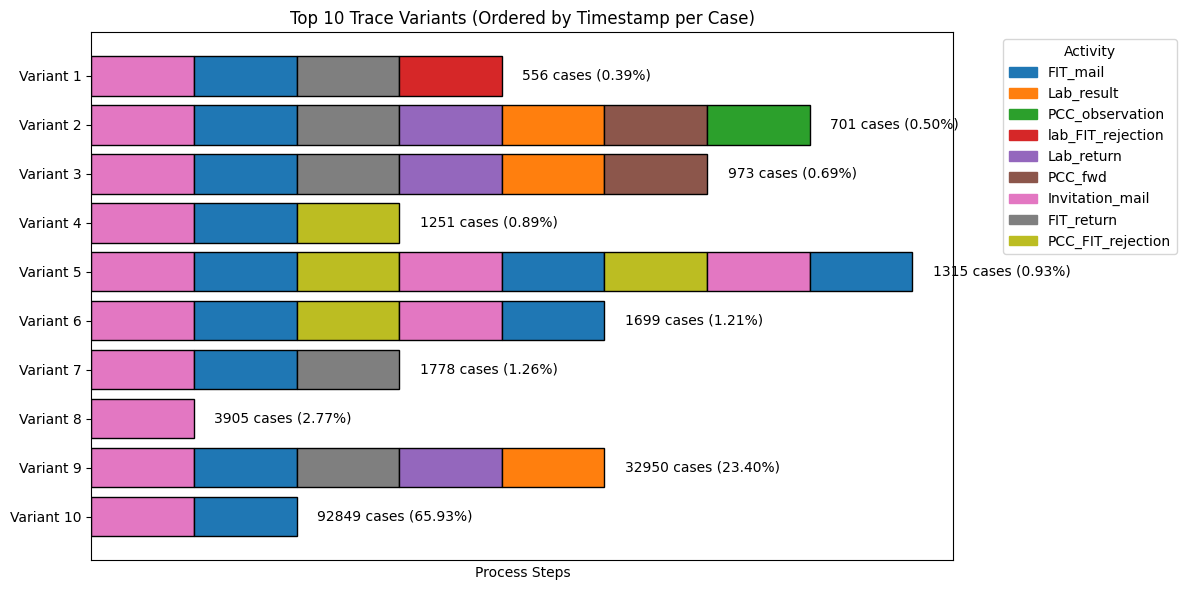

In [37]:
import pm4py
import matplotlib.pyplot as plt
import numpy as np

# ----------- 1. Extract Ordered Activity Sequences per Case -----------

ordered_variants = {}

for trace in event_log_xes_post2024:
    case_id = trace.attributes.get('concept:name', None)
    # Order events by timestamp to guarantee correct sequence
    ordered_events = sorted(trace, key=lambda e: e['time:timestamp'])
    activity_sequence = tuple(event['concept:name'] for event in ordered_events)
    # Collect all case IDs for this variant (could use for further analysis)
    ordered_variants.setdefault(activity_sequence, []).append(case_id)

# ----------- 2. Count Frequencies and Prepare for Visualization -----------

variant_counts = [(list(variant), len(case_ids)) for variant, case_ids in ordered_variants.items()]
variant_counts.sort(key=lambda x: x[1], reverse=True)

top_n = 10
top_variants = variant_counts[:top_n]
total_cases = sum(count for _, count in variant_counts)

# Collect all unique activities for coloring
all_activities = set(act for trace, _ in top_variants for act in trace)
activity_colors = {act: plt.cm.get_cmap("tab10")(i) for i, act in enumerate(all_activities)}

# ----------- 3. Visualization -----------

fig, ax = plt.subplots(figsize=(12, 6))

for i, (trace, count) in enumerate(top_variants):
    y_position = top_n - i
    for j, activity in enumerate(trace):
        ax.barh(
            y_position,
            width=1,
            left=j,
            color=activity_colors[activity],
            edgecolor="black",
        )
    ax.text(
        len(trace) + 0.2, y_position,
        f"{count} cases ({count / total_cases * 100:.2f}%)",
        va="center"
    )

ax.set_yticks(range(1, top_n + 1))
ax.set_yticklabels([f"Variant {i+1}" for i in range(top_n)])
ax.set_xlabel("Process Steps")
ax.set_title(f"Top {top_n} Trace Variants (Ordered by Timestamp per Case)")
ax.invert_yaxis()
ax.set_xticks([])

# Create legend for activities
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in activity_colors.values()]
labels = list(activity_colors.keys())
ax.legend(handles, labels, title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


## LOAD PRE 2024

In [38]:
from pm4py.objects.log.importer.xes import importer as xes_importer

# Caminho completo para o ficheiro XES
xes_file_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\AA_Datasets_may_2025\filtered_log_pre_2024.xes"

# Carregar o log de eventos XES
try:
    event_log_xes = xes_importer.apply(xes_file_path)
    print("Loaded XES event log successfully.")

    # Exibir as primeiras 10 traces (linhas) do log para inspeção
    for i, trace in enumerate(event_log_xes[:10]):
        print(f"Trace {i + 1}:")
        for event in trace:
            print(event)
        print("-" * 40)
except Exception as e:
    print(f"An error occurred while loading the XES file: {e}")

parsing log, completed traces :: 100%|██████████| 1042520/1042520 [02:09<00:00, 8020.28it/s] 


Loaded XES event log successfully.
Trace 1:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2019, 8, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2019, 9, 9, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2020, 8, 28, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 2:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'FIT_mail', 'time:timestamp': datetime.datetime(2022, 10, 5, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name': 'PCC_FIT_rejection', 'time:timestamp': datetime.datetime(2024, 2, 7, 0, 1, tzinfo=datetime.timezone.utc)}
----------------------------------------
Trace 3:
{'concept:name': 'Invitation_mail', 'time:timestamp': datetime.datetime(2022, 8, 31, 0, 1, tzinfo=datetime.timezone.utc)}
{'concept:name'

#### tracing pre_2024

C:\Users\hugof\AppData\Local\Temp\ipykernel_25340\307675756.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap("tab10")


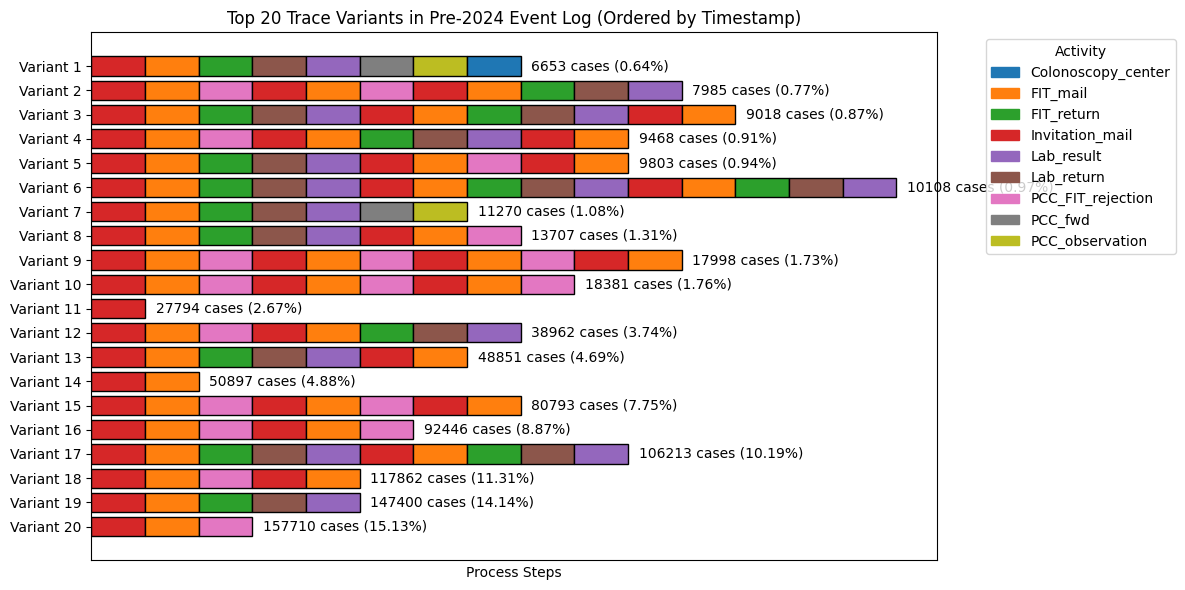

In [40]:
import pm4py
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Build time-ordered activity variants ---
ordered_variants = {}

for trace in event_log_xes:
    case_id = trace.attributes.get('concept:name', None)
    ordered_events = sorted(trace, key=lambda e: e['time:timestamp'])
    activity_sequence = tuple(event['concept:name'] for event in ordered_events)
    ordered_variants.setdefault(activity_sequence, []).append(case_id)

variant_counts = [(list(variant), len(case_ids)) for variant, case_ids in ordered_variants.items()]
variant_counts.sort(key=lambda x: x[1], reverse=True)

# --- 2. Visualization ---

top_n = 20
top_variants = variant_counts[:top_n]
total_cases = sum(count for _, count in variant_counts)

# Map all unique activities to colors (cycle if >10)
all_activities = sorted(set(act for trace, _ in top_variants for act in trace))
color_map = plt.cm.get_cmap("tab10")
activity_colors = {act: color_map(i % 10) for i, act in enumerate(all_activities)}

fig, ax = plt.subplots(figsize=(12, 6))

for i, (trace, count) in enumerate(top_variants):
    y_position = top_n - i
    for j, activity in enumerate(trace):
        ax.barh(
            y_position,
            width=1,
            left=j,
            color=activity_colors[activity],
            edgecolor="black",
        )
    ax.text(
        len(trace) + 0.2, y_position,
        f"{count} cases ({count / total_cases * 100:.2f}%)",
        va="center"
    )

ax.set_yticks(range(1, top_n + 1))
ax.set_yticklabels([f"Variant {i+1}" for i in range(top_n)])
ax.set_xlabel("Process Steps")
ax.set_title(f"Top {top_n} Trace Variants in Pre-2024 Event Log (Ordered by Timestamp)")
ax.invert_yaxis()
ax.set_xticks([])

# Legend
handles = [plt.Rectangle((0, 0), 1, 1, color=activity_colors[act]) for act in all_activities]
ax.legend(handles, all_activities, title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


## Petri RUN

### PETRI RUN PRE 2024 _ INDUCTIVE MINER

In [35]:
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from pm4py.objects.log.obj import EventLog
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.objects.petri_net.exporter import exporter as pnml_exporter
from pm4py.objects.petri_net.utils import petri_utils
from datetime import datetime
from IPython.display import display, Markdown

# ✅ Aplicar Inductive Miner (Process Tree)
process_tree = inductive_miner.apply(filtered_pre_2024_log)

# ✅ Converter Process Tree para rede de Petri
net, initial_marking, final_marking = pt_converter.apply(process_tree)

# ✅ Verificar e corrigir o final_marking, se necessário
if not isinstance(final_marking, dict) or not all(hasattr(place, "name") for place in final_marking):
    print("⚠️ Fixing `final_marking`...")
    final_marking = petri_utils.get_final_marking(net)
    print(f"✅ Fixed `final_marking`: {final_marking}")

# 📁 Caminhos para exportar
pnml_filename = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.pnml"
image_filename = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.png"

# 💾 Exportar a rede de Petri como PNML
pnml_exporter.apply(net, initial_marking, pnml_filename, final_marking)
print(f"✅ Petri Net saved as PNML: {pnml_filename}")

# 🖼️ Visualizar a rede de Petri
gviz = pn_visualizer.apply(net, initial_marking, final_marking)

# 💾 Guardar imagem da rede
pn_visualizer.save(gviz, image_filename)
print(f"✅ Petri Net saved as PNG: {image_filename}")

# 📢 Mostrar a imagem no notebook
markdown_text = f"![Petri Net Visualization](file:///{image_filename})"
display(Markdown(markdown_text))


✅ Petri Net saved as PNML: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.pnml
✅ Petri Net saved as PNG: C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.png


![Petri Net Visualization](file:///C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.png)

## Token Replay models

Atenção que é preciso fazer o load dos modelos a cada nova abertura de ambiente

O modelo "idealizado" já foi calculado previamente

In [36]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.petri_net.importer import importer as pnml_importer
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

# Load the event log for 2024
xes_2024_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\PRE 2024 data\filtered_log_pre_2024.xes"
event_log_2024 = xes_importer.apply(xes_2024_path)

# Load the Petri Net models
ideal_petri_net_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\IDEALIZED DATASET\idealized_petri_net.pnml"
real_world_petri_net_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.pnml"

# Load the Idealized Model
net_ideal, im_ideal, fm_ideal = pnml_importer.apply(ideal_petri_net_path)

# Load the Real-World Model
net_real, im_real, fm_real = pnml_importer.apply(real_world_petri_net_path)

# Apply Token-Based Replay for Idealized Model
replay_results_ideal = token_replay.apply(event_log_2024, net_ideal, im_ideal, fm_ideal)
fitness_ideal = sum(x["trace_fitness"] for x in replay_results_ideal) / len(replay_results_ideal)

# Apply Token-Based Replay for Real-World Model
replay_results_real = token_replay.apply(event_log_2024, net_real, im_real, fm_real)
fitness_real = sum(x["trace_fitness"] for x in replay_results_real) / len(replay_results_real)

# Display Fitness Scores
print(f"Fitness (2024 log vs Idealized Model): {fitness_ideal:.4f}")
print(f"Fitness (2024 log vs Real-World Model): {fitness_real:.4f}")

parsing log, completed traces ::  27%|██▋       | 277746/1042520 [09:47<26:57, 472.83it/s] 


KeyboardInterrupt: 

## Alignment run

In [ ]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.petri_net.importer.importer import apply as pnml_importer
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

import pandas as pd

# Load the updated event log for 2024
xes_2024_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\PRE 2024 data\filtered_log_pre_2024.xes"
event_log_2024 = xes_importer.apply(xes_2024_path)

# Load the Petri Net models
ideal_petri_net_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\IDEALIZED DATASET\idealized_petri_net.pnml"
real_world_petri_net_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\ipetri_net_pre_2024.pnml"

# Load the Idealized Model
net_ideal, im_ideal, fm_ideal = pnml_importer(ideal_petri_net_path)

# Load the Real-World Model
net_real, im_real, fm_real = pnml_importer(real_world_petri_net_path)

# Apply Alignment-Based Conformance for Idealized Model
alignment_results_ideal = alignments.apply_log(event_log_2024, net_ideal, im_ideal, fm_ideal)
fitness_ideal = sum(x["fitness"] for x in alignment_results_ideal) / len(alignment_results_ideal)

# Apply Alignment-Based Conformance for Real-World Model
alignment_results_real = alignments.apply_log(event_log_2024, net_real, im_real, fm_real)
fitness_real = sum(x["fitness"] for x in alignment_results_real) / len(alignment_results_real)

# Display Fitness Scores
print(f"Alignment Fitness (2024 log vs Idealized Model): {fitness_ideal:.4f}")
print(f"Alignment Fitness (2024 log vs Real-World Model): {fitness_real:.4f}")

aligning log, completed variants :: 100%|██████████| 135/135 [00:01<00:00, 79.61it/s]

Alignment Fitness (2024 log vs Idealized Model): 0.7025
Alignment Fitness (2024 log vs Real-World Model): 1.0000


## Precision 

In [ ]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.precision.algorithm import Variants

import pandas as pd

# Load the updated event log for 2024
xes_2024_path = r"C:\Users\hugof\OneDrive - SPMS - Serviços Partilhados do Ministério da Saúde, EPE\DEP\Rastreios\RCCR\PM_mining\run_R_pm_phd\ARTIGO 3\PRE 2024 data\filtered_log_pre_2024.xes"
event_log_2024 = xes_importer.apply(xes_2024_path)

# Compute Token-Based Precision for Idealized Model
precision_ideal = precision_evaluator.apply(
    event_log_2024, net_ideal, im_ideal, fm_ideal, variant=Variants.ETCONFORMANCE_TOKEN
)
print(f"Token-Based Precision (2024 log vs Idealized Model): {precision_ideal:.4f}")

# Compute Token-Based Precision for Real-World Model
precision_real = precision_evaluator.apply(
    event_log_2024, net_real, im_real, fm_real, variant=Variants.ETCONFORMANCE_TOKEN
)
print(f"Token-Based Precision (2024 log vs Real-World Model): {precision_real:.4f}")

# Compute Alignment-Based Precision for Idealized Model
precision_ideal_alignment = precision_evaluator.apply(
    event_log_2024, net_ideal, im_ideal, fm_ideal, variant=Variants.ALIGN_ETCONFORMANCE
)
print(f"Alignment-Based Precision (2024 log vs Idealized Model): {precision_ideal_alignment:.4f}")

# Compute Alignment-Based Precision for Real-World Model
precision_real_alignment = precision_evaluator.apply(
    event_log_2024, net_real, im_real, fm_real, variant=Variants.ALIGN_ETCONFORMANCE
)
print(f"Alignment-Based Precision (2024 log vs Real-World Model): {precision_real_alignment:.4f}")

replaying log with TBR, completed traces :: 100%|██████████| 607/607 [00:00<00:00, 6868.12it/s]


Token-Based Precision (2024 log vs Idealized Model): 1.0000


replaying log with TBR, completed traces :: 100%|██████████| 607/607 [00:01<00:00, 379.99it/s]


Token-Based Precision (2024 log vs Real-World Model): 0.7518


computing precision with alignments, completed variants :: 100%|██████████| 607/607 [00:00<00:00, 711.46it/s]


Alignment-Based Precision (2024 log vs Idealized Model): 1.0000


computing precision with alignments, completed variants :: 100%|██████████| 607/607 [00:02<00:00, 253.98it/s]


Alignment-Based Precision (2024 log vs Real-World Model): 0.7518


# CORTE DOS WORKCYCLES